In [1]:

import torch
from transformers import AutoModel

# parameter check
model = AutoModel.from_pretrained("skt/kobert-base-v1")

state_dict = model.state_dict()

total_params = 0
total_bytes = 0

print(f"{'Name':80s} {'Shape':40s} {'Dtype':20s} {'Bytes'}")
print("-" * 140)

for name, param in state_dict.items():
    numel = param.numel()
    dtype = param.dtype
    bytes_per_elem = torch.finfo(dtype).bits // 8 if dtype.is_floating_point else torch.iinfo(dtype).bits // 8
    size_bytes = numel * bytes_per_elem

    total_params += numel
    total_bytes += size_bytes

    print(f"{name:80s} {str(tuple(param.shape)):40s} {str(dtype):20s} {size_bytes}")

print("-" * 140)
print(f"Total Parameters: {total_params:,}")
print(f"Estimated Memory Size: {total_bytes / (1024**2):.2f} MB")


""" =========================================================== """


# half parameters
model = model.half()

# 실제 모델의 파라미터를 담고있는 state_dict 값 분석
state_dict = model.state_dict()


total_params = 0
total_bytes = 0

print(f"{'Name':80s} {'Shape':40s} {'Dtype':20s} {'Bytes'}")
print("-" * 140)

for name, param in state_dict.items():
    numel = param.numel()
    dtype = param.dtype
    bytes_per_elem = torch.finfo(dtype).bits // 8 if dtype.is_floating_point else torch.iinfo(dtype).bits // 8
    size_bytes = numel * bytes_per_elem

    total_params += numel
    total_bytes += size_bytes

    print(f"{name:80s} {str(tuple(param.shape)):40s} {str(dtype):20s} {size_bytes}")

print("-" * 140)
print(f"Total Parameters: {total_params:,}")
print(f"Estimated Memory Size: {total_bytes / (1024 ** 2):.2f} MB")

torch.save(model.state_dict(), "fp16_kobert.pt")

config.json:   0%|          | 0.00/535 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Name                                                                             Shape                                    Dtype                Bytes
--------------------------------------------------------------------------------------------------------------------------------------------
embeddings.word_embeddings.weight                                                (8002, 768)                              torch.float32        24582144
embeddings.position_embeddings.weight                                            (512, 768)                               torch.float32        1572864
embeddings.token_type_embeddings.weight                                          (2, 768)                                 torch.float32        6144
embeddings.LayerNorm.weight                                                      (768,)                                   torch.float32        3072
embeddings.LayerNorm.bias                                                        (768,)                        

In [2]:
import pandas as pd
mpg = pd.read_csv('https://gist.githubusercontent.com/wmeints/80c1ba22ceeb7a29a0e5e979f0b0afba/raw/8629fe51f0e7642fc5e05567130807b02a93af5e/auto-mpg.csv', na_values = "?")
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [3]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [4]:
mpg = mpg.dropna()
mpg.isna().sum(axis=0)

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [5]:
X_data = mpg.drop(['mpg', 'car name'], axis=1)
X_data.head()

,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,8,307.0,130.0,3504,12.0,70,1
1,8,350.0,165.0,3693,11.5,70,1
2,8,318.0,150.0,3436,11.0,70,1
3,8,304.0,150.0,3433,12.0,70,1
4,8,302.0,140.0,3449,10.5,70,1


In [6]:
y_data = mpg['mpg']
y_data.head()

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(313, 7) (79, 7)
(313,) (79,)


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(X_train_s[:5])

[[ 0.30486156  0.28457757  0.14142863  0.75480297  1.1217589   0.49452752
  -0.68982474]
 [-0.87318372 -0.53588042 -0.32949862 -0.49312922 -0.22893966 -0.0572982
  -0.68982474]
 [ 0.30486156 -0.23665456 -0.19868549 -0.00252992 -0.37111846 -0.33321105
  -0.68982474]
 [ 1.48290683  1.18225513  1.18793363  1.3680521  -0.72656545 -1.16094962
  -0.68982474]
 [-0.87318372 -1.05711255 -1.06205212 -1.32309939  0.30423083  1.32226608
  -0.68982474]]


In [9]:
y_train = y_train.values
y_test = y_test.values
print(type(y_train), type(y_test))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
 layers.Dense(64, activation='relu', input_shape=(7,)),
 layers.Dense(64, activation='relu'),
 layers.Dense(1)
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='mse', optimizer='adam',
       metrics=['mae', 'mse'])

In [12]:
EPOCHS = 200
BATCH_SIZE = 32
history = model.fit(X_train_s, y_train,
         epochs=EPOCHS,
         batch_size=BATCH_SIZE,
         validation_split = 0.2,
         verbose=1)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 577ms/step - loss: 584.7272 - mae: 22.7481 - mse: 584.7272 - val_loss: 650.1784 - val_mae: 24.2152 - val_mse: 650.1784
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 553.4394 - mae: 22.0532 - mse: 553.4394 - val_loss: 615.9732 - val_mae: 23.4954 - val_mse: 615.9732
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 520.3894 - mae: 21.2600 - mse: 520.3894 - val_loss: 576.6685 - val_mae: 22.6512 - val_mse: 576.6685
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 481.3847 - mae: 20.3245 - mse: 481.3847 - val_loss: 528.7397 - val_mae: 21.5848 - val_mse: 528.7397
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 434.5223 - mae: 19.1221 - mse: 434.5223 - val_loss: 469.3175 - val_mae: 20.1977 - val_mse: 469.3175
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 377.9761 - mae: 17.6062 - mse: 377.9761 - val_loss: 400.0878 - val_mae: 18.4609 - val_mse: 400.0878
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step 

In [13]:
history.history.keys()

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])

In [14]:
import matplotlib.pyplot as plt
def plot_history(history):
 hist = pd.DataFrame(history.history)
 hist['epoch'] = history.epoch
 plt.figure(figsize=(16,8))
 plt.subplot(1,2,1)
 plt.xlabel('Epoch')
 plt.ylabel('Mean Abs Error [MPG]')
 plt.plot(hist['epoch'], hist['mae'], label='Train Error')
 plt.plot(hist['epoch'], hist['val_mae'], label = 'Val Error')
 plt.ylim([0,5])
 plt.legend()

 plt.subplot(1,2,2)
 plt.xlabel('Epoch')
 plt.ylabel('Mean Square Error [$MPG^2$]')
 plt.plot(hist['epoch'], hist['mse'], label='Train Error')
 plt.plot(hist['epoch'], hist['val_mse'], label = 'Val Error')
 plt.ylim([0,20])
 plt.legend()
 plt.show()

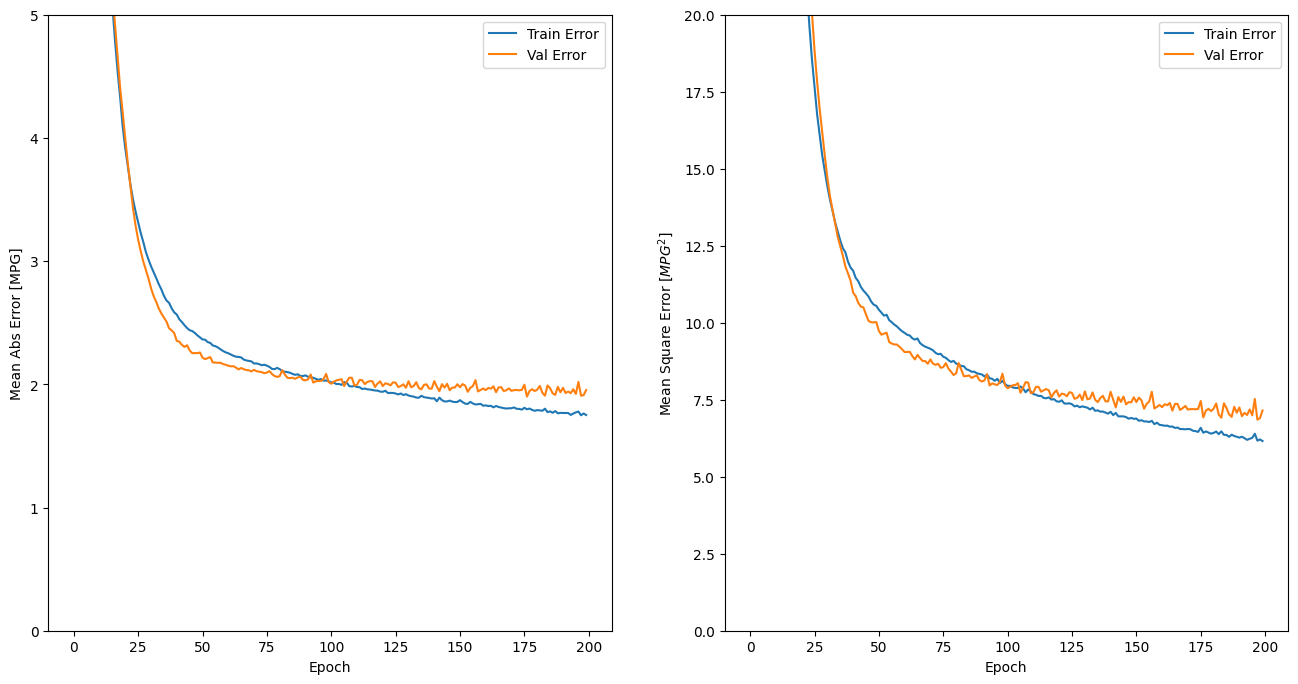

In [15]:
plot_history(history)

In [16]:
loss, mae, mse = model.evaluate(X_test_s, y_test, verbose=2)

3/3 - 0s - 97ms/step - loss: 6.5495 - mae: 1.8131 - mse: 6.5495


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


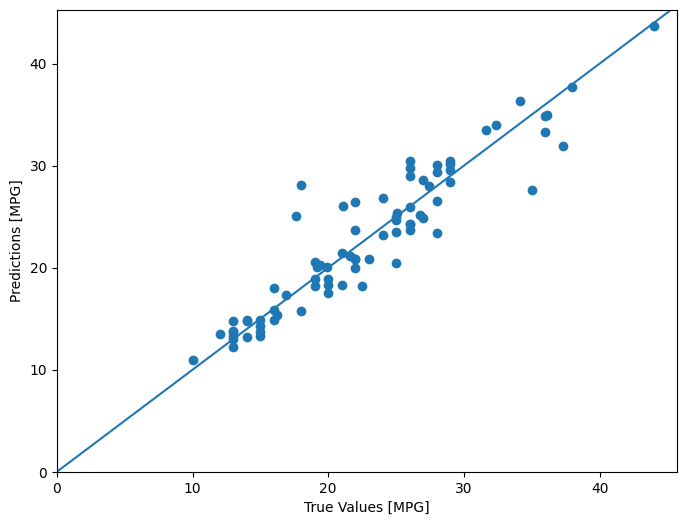

In [17]:
y_pred = model.predict(X_test_s)

y_pred = y_pred.flatten()
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])
plt.plot([-100, 100], [-100, 100])
plt.show()

In [18]:
import pandas as pd
diabetes = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/refs/heads/master/diabetes.csv')
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
diabetes.isna().sum(axis=0)

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [20]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness',
'Insulin', 'BMI']
(diabetes[cols] == 0).sum(axis=0)

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


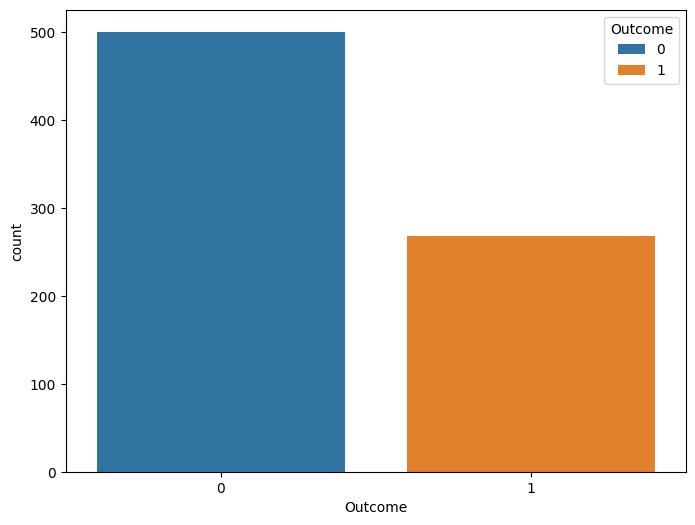

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.countplot(x='Outcome', data = diabetes, hue='Outcome')
plt.show()

In [22]:
diabetes['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [23]:
X_data = diabetes.drop(['Outcome'], axis=1)
y_data = diabetes['Outcome']

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_data,y_data,
 test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(614, 8) (154, 8)
(614,) (154,)


In [25]:
import numpy as np
def impute_zero(data, col):
  df = data.loc[data[col] != 0, col]
  avg = np.sum(df) / len(df)
  k = len(data.loc[ data[col] == 0, col])
  data.loc[ data[col] == 0, col ] = avg
  print('%s : fixed %d, mean: %.3f' % (col, k, avg))
for col in cols:
  impute_zero(X_train, col)

Glucose : fixed 5, mean: 121.847
BloodPressure : fixed 24, mean: 72.239
SkinThickness : fixed 176, mean: 28.596
Insulin : fixed 290, mean: 154.330
BMI : fixed 7, mean: 32.352


/tmp/ipykernel_1052/1791719594.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '121.84729064039409' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[ data[col] == 0, col ] = avg
/tmp/ipykernel_1052/1791719594.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '72.23898305084745' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[ data[col] == 0, col ] = avg
/tmp/ipykernel_1052/1791719594.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '28.595890410958905' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[ data[col] == 0, col ] = avg
/tmp/ipykernel_1052/1791719594.py:6: FutureWarning: Setting an

In [26]:
(X_train[cols] == 0).sum(axis=0)

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


In [27]:
for col in cols:
  impute_zero(X_test, col)

Glucose : fixed 0, mean: 121.052
BloodPressure : fixed 11, mean: 73.091
SkinThickness : fixed 51, mean: 31.524
Insulin : fixed 84, mean: 161.186
BMI : fixed 4, mean: 32.883


/tmp/ipykernel_1052/1791719594.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '121.05194805194805' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[ data[col] == 0, col ] = avg
/tmp/ipykernel_1052/1791719594.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '73.0909090909091' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[ data[col] == 0, col ] = avg
/tmp/ipykernel_1052/1791719594.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '31.524271844660195' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[ data[col] == 0, col ] = avg
/tmp/ipykernel_1052/1791719594.py:6: FutureWarning: Setting an 

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(X_train_s[:5])

[[-5.26396861e-01 -1.25832567e+00  0.00000000e+00  4.22787785e-16
   0.00000000e+00  1.02533391e-15 -4.90734790e-01 -1.03594038e+00]
 [ 1.58804586e+00 -3.27397242e-01  8.07407436e-01 -5.46930179e-01
   0.00000000e+00 -5.99178052e-01  2.41502991e+00  1.48710085e+00]
 [-8.28460107e-01  5.70283740e-01 -2.17042447e+00 -1.14195109e+00
  -8.20791983e-01 -5.27026593e-01  5.49160552e-01 -9.48938958e-01]
 [-1.13052335e+00  1.30172750e+00 -1.83955426e+00  4.22787785e-16
   0.00000000e+00 -1.50828644e+00 -6.39291267e-01  2.79212217e+00]
 [ 6.81856121e-01  4.04046521e-01  6.41972330e-01  1.00012419e+00
   2.48169622e+00  1.99827450e+00 -6.86829340e-01  1.13909516e+00]]


In [29]:
y_train = y_train.values
y_test = y_test.values
print(type(y_train), type(y_test))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [30]:
from tensorflow import keras
from tensorflow.keras import layers
def build_model():
  model = keras.Sequential()
  model.add(layers.Dense(12, input_dim=8, activation='relu'))
  model.add(layers.Dense(8, activation='relu'))
  model.add(layers.Dense(1, activation='sigmoid'))
  return model

In [31]:
model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(loss='binary_crossentropy',
      optimizer='adam',
      metrics=['acc'])

In [33]:
EPOCHS = 500
BATCH_SIZE = 16
history = model.fit(X_train_s, y_train,
         epochs=EPOCHS,
         batch_size=BATCH_SIZE,
         validation_split = 0.2,
         verbose=1)

Epoch 1/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - acc: 0.4155 - loss: 0.7912 - val_acc: 0.4959 - val_loss: 0.7611
Epoch 2/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.5479 - loss: 0.7151 - val_acc: 0.5691 - val_loss: 0.7076
Epoch 3/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6029 - loss: 0.6657 - val_acc: 0.6179 - val_loss: 0.6671
Epoch 4/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.6599 - loss: 0.6278 - val_acc: 0.6585 - val_loss: 0.6358
Epoch 5/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6986 - loss: 0.5968 - val_acc: 0.6504 - val_loss: 0.6075
Epoch 6/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.7088 - loss: 0.5692 - val_acc: 0.6585 - val_loss: 0.5808
Epoch 7/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.7271 - loss: 0.5463 - val_acc: 0.6911 - val_loss: 0.5575
Epoch 8/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.7352 - loss: 0.5274 - val_acc: 0.6992 - val_loss: 0.5353
Epoch 9/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.747

In [34]:
import matplotlib.pyplot as plt
def plot_history(history):
 hist = pd.DataFrame(history.history)
 hist['epoch'] = history.epoch
 plt.figure(figsize=(16,8))
 plt.subplot(1,2,1)
 plt.xlabel('Epoch')
 plt.ylabel('Loss')
 plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
 plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
 plt.legend()

 plt.subplot(1,2,2)
 plt.xlabel('Epoch')
 plt.ylabel('Accuracy')
 plt.plot(hist['epoch'], hist['acc'], label='Train Accuracy')
 plt.plot(hist['epoch'], hist['val_acc'], label = 'Val Accuracy')
 plt.legend()

 plt.show()

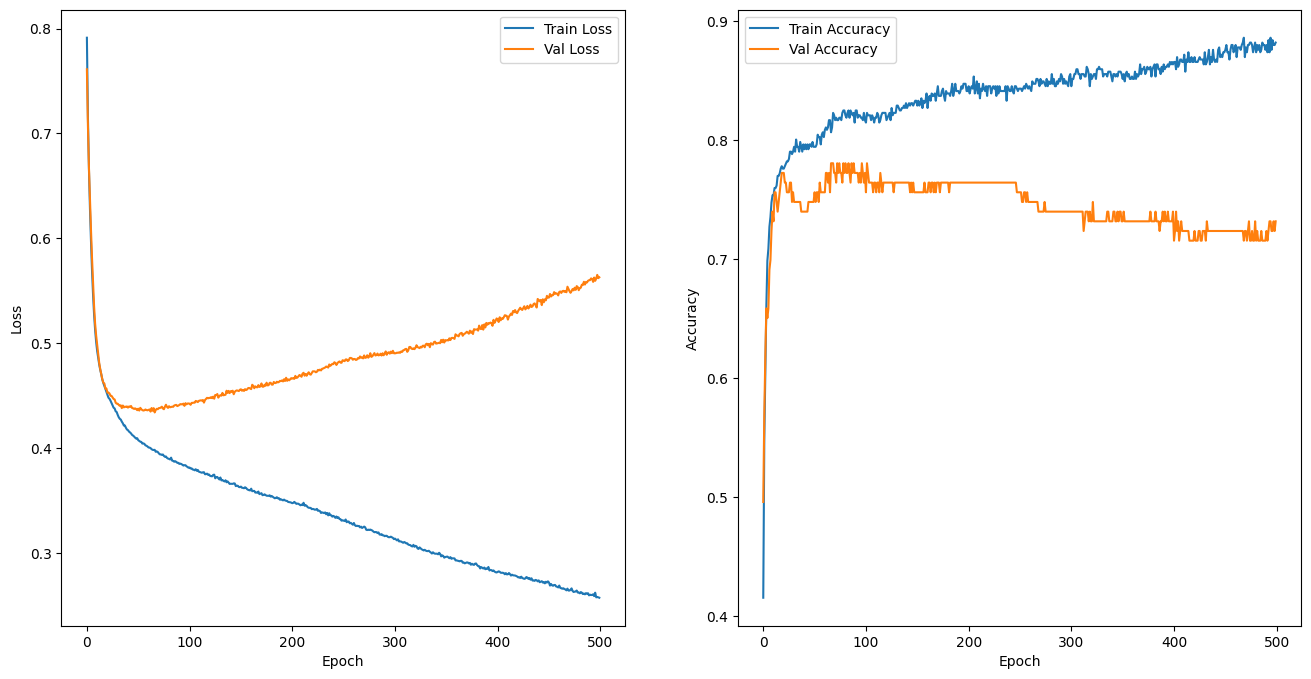

In [35]:
plot_history(history)

In [36]:
from tensorflow import keras
model = build_model()
model.compile(loss='binary_crossentropy',
      optimizer='adam',
      metrics=['acc'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
early_stop = keras.callbacks.EarlyStopping(
 monitor='val_loss', patience=10)

In [38]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
EPOCHS = 500
BATCH_SIZE = 16
history = model.fit(X_train_s, y_train,
         epochs=EPOCHS,
         batch_size=BATCH_SIZE,
         validation_split = 0.2,
         callbacks=[early_stop],
         verbose=1)

Epoch 1/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - acc: 0.3625 - loss: 0.8168 - val_acc: 0.4797 - val_loss: 0.7199
Epoch 2/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.4440 - loss: 0.7356 - val_acc: 0.5528 - val_loss: 0.6727
Epoch 3/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.5682 - loss: 0.6822 - val_acc: 0.6098 - val_loss: 0.6402
Epoch 4/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6253 - loss: 0.6426 - val_acc: 0.6504 - val_loss: 0.6114
Epoch 5/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6680 - loss: 0.6099 - val_acc: 0.6748 - val_loss: 0.5846
Epoch 6/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7047 - loss: 0.5806 - val_acc: 0.6829 - val_loss: 0.5615
Epoch 7/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7373 - loss: 0.5570 - val_acc: 0.7154 - val_loss: 0.5411
Epoch 8/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7495 - loss: 0.5373 - val_acc: 0.7073 - val_loss: 0.5255
Epoch 9/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.745

In [39]:
y_pred = model.predict(X_test_s)
y_pred= (y_pred >0.5).astype(np.int32).flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


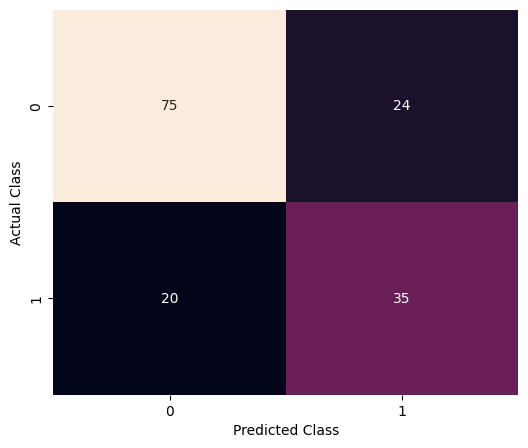

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cf_matrix, annot=True, cbar=False)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score
def print_score(y_test, y_pred):
  print('precision: %.3f' % (precision_score(y_test, y_pred)))
  print('recall_score: %.3f' % (recall_score(y_test, y_pred)))
  print('f1_score: %.3f' % (f1_score(y_test, y_pred)))

In [42]:
print_score(y_test, y_pred)

precision: 0.593
recall_score: 0.636
f1_score: 0.614


In [43]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.76      0.77        99
           1       0.59      0.64      0.61        55

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.71      0.72       154



# 1-5

In [189]:
import pandas as pd

penguins = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/penguins.csv')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [190]:
penguins['species'].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [191]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [192]:
penguins.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [193]:
penguins = penguins.dropna()
penguins.isna().sum(axis=0)

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [194]:
X = penguins.drop(['species'], axis=1)
y = penguins["species"]

In [195]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
             test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(266, 6) (266,)
(67, 6) (67,)


In [196]:
df = X_train[['bill_length_mm','bill_depth_mm',
      'flipper_length_mm', 'body_mass_g']]
df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
230,40.9,13.7,214.0,4650.0
84,37.3,17.8,191.0,3350.0
303,50.0,15.9,224.0,5350.0
22,35.9,19.2,189.0,3800.0
29,40.5,18.9,180.0,3950.0


In [197]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_s = scaler.fit_transform(df)
df_s

array([[0.32      , 0.07142857, 0.71186441, 0.54166667],
       [0.18909091, 0.55952381, 0.3220339 , 0.18055556],
       [0.65090909, 0.33333333, 0.88135593, 0.73611111],
       ...,
       [0.27636364, 0.54761905, 0.3559322 , 0.13888889],
       [0.48727273, 0.22619048, 0.81355932, 0.63888889],
       [0.21818182, 0.46428571, 0.15254237, 0.13194444]])

In [198]:
dfX = pd.DataFrame(df_s,
 columns=['bill_length_mm','bill_depth_mm',
                 'flipper_length_mm', 'body_mass_g'])

In [199]:
dfX['island']= X_train['island'].map(
{'Biscoe': 0, 'Dream': 1, 'Torgersen': 2}).reset_index(drop = True)
dfX['sex'] = X_train['sex'].map(
{'FEMALE': 0, 'MALE': 1}).reset_index(drop = True)
dfy = y_train.map(
{'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}).reset_index(drop = True)

In [200]:
from tensorflow.keras import utils

y_train = utils.to_categorical(dfy)
y_train[:20]

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [201]:
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
  layers.Dense(32, activation='relu', input_shape=(6,)),
  layers.Dense(16, activation='relu'),
  layers.Dense(8, activation='relu'),
  layers.Dense(3, activation='softmax')   ## 다중 분류
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 915 (3.57 KB)

 Trainable params: 915 (3.57 KB)

 Non-trainable params: 0 (0.00 B)

In [202]:
model.compile(loss='categorical_crossentropy',
      optimizer='adam',
      metrics=['acc'])

In [203]:
EPOCHS = 100
BATCH_SIZE = 32
history = model.fit(dfX, y_train,
         epochs=EPOCHS,
         batch_size=BATCH_SIZE,
         validation_split=0.2)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 233ms/step - acc: 0.1038 - loss: 1.1057 - val_acc: 0.2407 - val_loss: 1.0720
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.2264 - loss: 1.0739 - val_acc: 0.4074 - val_loss: 1.0461
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.4057 - loss: 1.0517 - val_acc: 0.4444 - val_loss: 1.0303
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.4245 - loss: 1.0370 - val_acc: 0.4444 - val_loss: 1.0177
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.4245 - loss: 1.0224 - val_acc: 0.4444 - val_loss: 1.0031
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.4245 - loss: 1.0050 - val_acc: 0.4444 - val_loss: 0.9858
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.4292 - loss: 0.9849 - val_acc: 0.4444 - val_loss: 0.9663
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.4292 - loss: 0.9614 - val_acc: 0.4444 - val_loss: 0.9438
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.4292 - loss:

In [204]:
import matplotlib.pyplot as plt
def plot_history(history):
 hist = pd.DataFrame(history.history)
 hist['epoch'] = history.epoch
 plt.figure(figsize=(16,8))
 plt.subplot(1,2,1)
 plt.xlabel('Epoch')
 plt.ylabel('Loss')
 plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
 plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')

 plt.legend()
 plt.subplot(1,2,2)
 plt.xlabel('Epoch')
 plt.ylabel('Accuracy')
 plt.plot(hist['epoch'], hist['acc'], label='Train Accuracy')
 plt.plot(hist['epoch'], hist['val_acc'], label = 'Val Accuracy')
 plt.legend()

 plt.show()

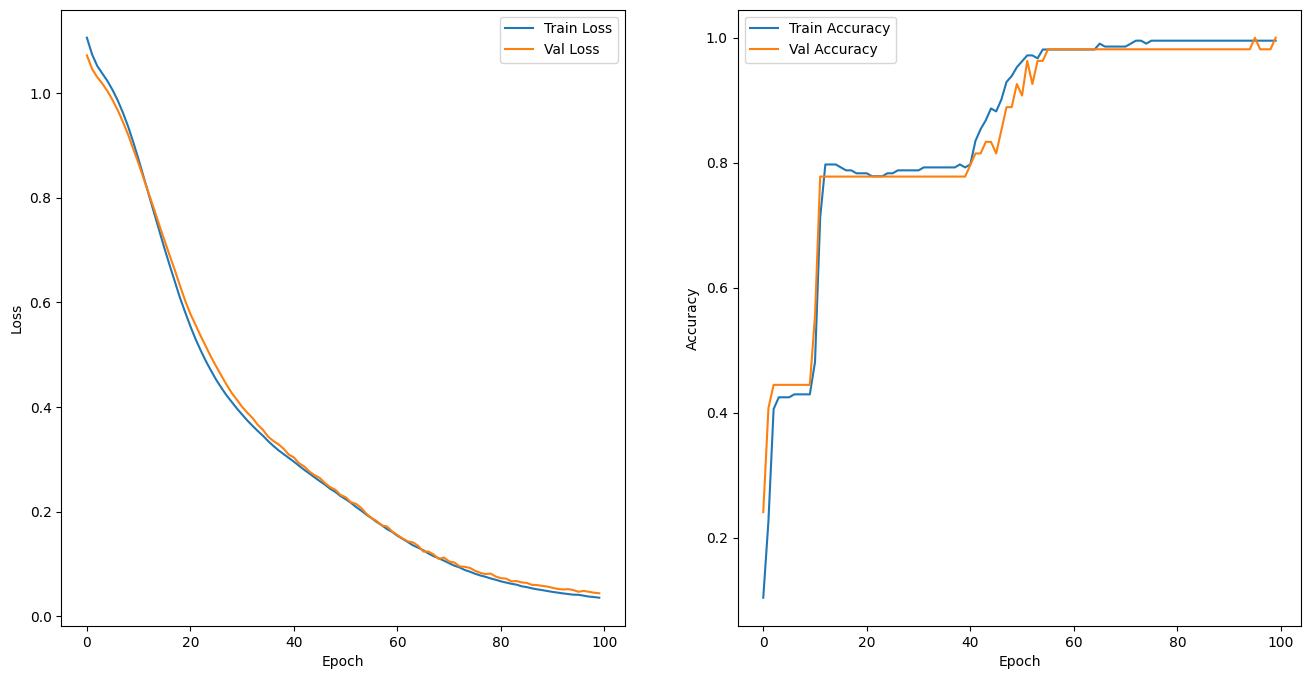

In [205]:
plot_history(history)

In [162]:
df = X_test[['bill_length_mm','bill_depth_mm',
      'flipper_length_mm', 'body_mass_g']]
df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
30,39.5,16.7,178.0,3250.0
317,46.9,14.6,222.0,4875.0
79,42.1,19.1,195.0,4000.0
201,49.8,17.3,198.0,3675.0
63,41.1,18.2,192.0,4050.0


In [163]:
df_s = scaler.transform(df)
df_s[:10]

array([[0.26909091, 0.42857143, 0.10169492, 0.15277778],
       [0.53818182, 0.17857143, 0.84745763, 0.60416667],
       [0.36363636, 0.71428571, 0.38983051, 0.36111111],
       [0.64363636, 0.5       , 0.44067797, 0.27083333],
       [0.32727273, 0.60714286, 0.33898305, 0.375     ],
       [0.46545455, 0.08333333, 0.6779661 , 0.56944444],
       [0.67636364, 0.22619048, 0.86440678, 0.79166667],
       [0.64      , 0.6547619 , 0.38983051, 0.25      ],
       [0.63636364, 0.60714286, 0.3559322 , 0.29861111],
       [0.70181818, 0.70238095, 0.49152542, 0.34722222]])

In [164]:
dfX = pd.DataFrame(df_s, columns=['bill_length_mm','bill_depth_mm',
                'flipper_length_mm', 'body_mass_g'])
dfX.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,0.269091,0.428571,0.101695,0.152778
1,0.538182,0.178571,0.847458,0.604167
2,0.363636,0.714286,0.389831,0.361111
3,0.643636,0.500000,0.440678,0.270833
4,0.327273,0.607143,0.338983,0.375000


In [165]:
dfX['island']= X_test['island'].map(
{'Biscoe': 0, 'Dream': 1, 'Torgersen': 2}).reset_index(drop = True)
dfX['sex'] = X_test['sex'].map(
 {'FEMALE': 0, 'MALE': 1}).reset_index(drop = True)
dfX.head(10)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island,sex
0,0.269091,0.428571,0.101695,0.152778,1,0
1,0.538182,0.178571,0.847458,0.604167,0,0
2,0.363636,0.714286,0.389831,0.361111,2,1
3,0.643636,0.500000,0.440678,0.270833,1,0
4,0.327273,0.607143,0.338983,0.375000,0,1
5,0.465455,0.083333,0.677966,0.569444,0,0
6,0.676364,0.226190,0.864407,0.791667,0,1
7,0.640000,0.654762,0.389831,0.250000,1,1
8,0.636364,0.607143,0.355932,0.298611,1,1
9,0.701818,0.702381,0.491525,0.347222,1,1


In [166]:
dfy = y_test.map({'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}).reset_index(drop = True)
dfy

,species
0,0
1,2
2,0
3,1
4,0
...,...
62,2
63,0
64,0
65,2


In [167]:
X_test = dfX.values
y_test = dfy.values
X_test = X_test.astype('float32')

In [168]:
y_pred = model.predict(X_test)
y_pred[:5]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


array([[0.8161159 , 0.0855779 , 0.09830625],
       [0.00157866, 0.00136629, 0.99705505],
       [0.992714  , 0.0016311 , 0.00565495],
       [0.35835582, 0.39460176, 0.24704234],
       [0.9641576 , 0.00835646, 0.02748598]], dtype=float32)

In [169]:
y_pred = np.argmax(y_pred, axis=1)
y_pred[:10]

array([0, 2, 0, 1, 0, 2, 2, 1, 1, 1])

In [170]:
from sklearn.metrics import confusion_matrix
cf_matrix = confusion_matrix(y_test, y_pred)
print(cf_matrix)

[[31  0  0]
 [ 0 13  0]
 [ 0  0 23]]


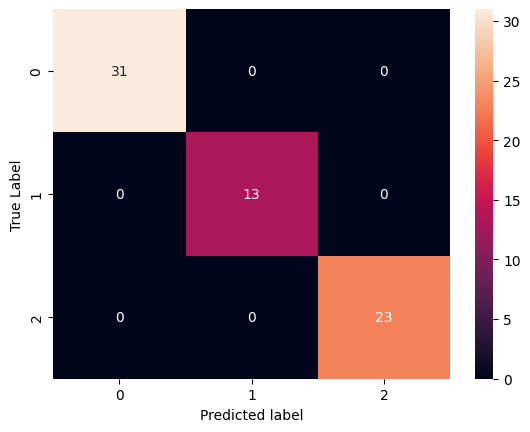

In [171]:
import seaborn as sns
sns.heatmap(cf_matrix, annot=True)
plt.ylabel('True Label')
plt.xlabel('Predicted label')
plt.show()

In [173]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score
def print_scores(y_true, y_pred):
  print('accuracy_score: {0:.4f}'.format(
    accuracy_score(y_true, y_pred)))
  print('precision_score: {0:.4f}'.format(
    precision_score(y_true, y_pred, average='macro')))
  print('recall_score: {0:.4f}'.format(
    recall_score(y_true, y_pred, average='macro')))
print_scores(y_test, y_pred)

accuracy_score: 1.0000
precision_score: 1.0000
recall_score: 1.0000


# 1-6

In [227]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


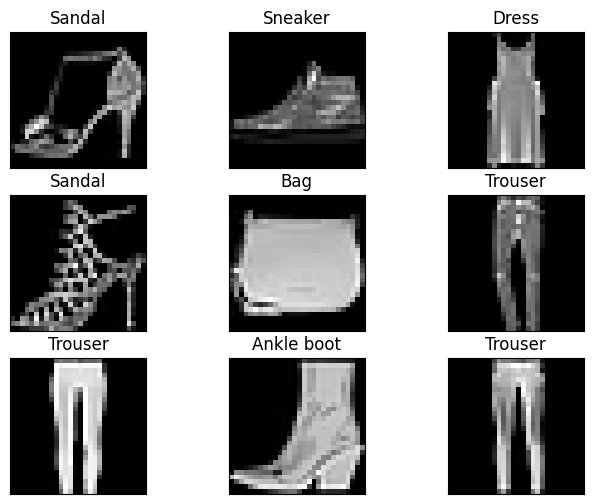

In [228]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover',
 'Dress', 'Coat', 'Sandal',
 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

samples = np.random.randint(len(X_train), size=9)

plt.figure(figsize = (8, 6))

for i, idx in enumerate(samples):
  plt.subplot(3, 3, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(X_train[idx], cmap = 'gray')
  plt.title(class_names[y_train[idx]])
plt.show()

In [229]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.3, random_state = 42)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(42000, 28, 28) (42000,)
(18000, 28, 28) (18000,)


In [230]:
import numpy as np

X_train = X_train.astype('float32') / 255.
X_val = X_val.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

print(np.max(X_train), np.min(X_train))

1.0 0.0


In [231]:
X_train = (X_train.reshape((-1, 28 * 28)))
X_val = (X_val.reshape((-1, 28 * 28)))
X_test = (X_test.reshape((-1, 28 * 28)))

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(42000, 784) (42000,)
(18000, 784) (18000,)
(10000, 784) (10000,)


In [232]:
from tensorflow.keras.utils import to_categorical
y_train_oh = to_categorical(y_train)
y_val_oh = to_categorical(y_val)
y_test_oh = to_categorical(y_test)

y_train_oh[:5]

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]])

In [233]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model():
  model = keras.Sequential()
  model.add(layers.Flatten(input_shape=(784,)))
  model.add(layers.Dense(64, activation = 'relu',input_shape=(784,)))
  model.add(layers.Dense(32, activation = 'relu'))
  model.add(layers.Dense(10, activation = 'softmax'))
  return model

In [234]:
model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

In [235]:
adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=adam,
       loss = 'categorical_crossentropy',
       metrics=['acc'])

In [236]:
EPOCHS = 30
BATCH_SIZE = 64
history = model.fit(X_train, y_train_oh,
         epochs = EPOCHS,
         batch_size = BATCH_SIZE,
         validation_data = (X_val, y_val_oh),
         verbose = 1)

Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.7884 - loss: 0.6192 - val_acc: 0.8374 - val_loss: 0.4660
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8513 - loss: 0.4270 - val_acc: 0.8453 - val_loss: 0.4340
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8610 - loss: 0.3854 - val_acc: 0.8647 - val_loss: 0.3803
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8710 - loss: 0.3559 - val_acc: 0.8685 - val_loss: 0.3663
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8791 - loss: 0.3343 - val_acc: 0.8756 - val_loss: 0.3474
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8835 - loss: 0.3181 - val_acc: 0.8759 - val_loss: 0.3439
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8895 - loss: 0.3049 - val_acc: 0.8760 - val_loss: 0.3443
Epoch 8/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8914 - loss: 0.2940 - val_acc: 0.8703 - val_loss: 0.3602
Epoch 9/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

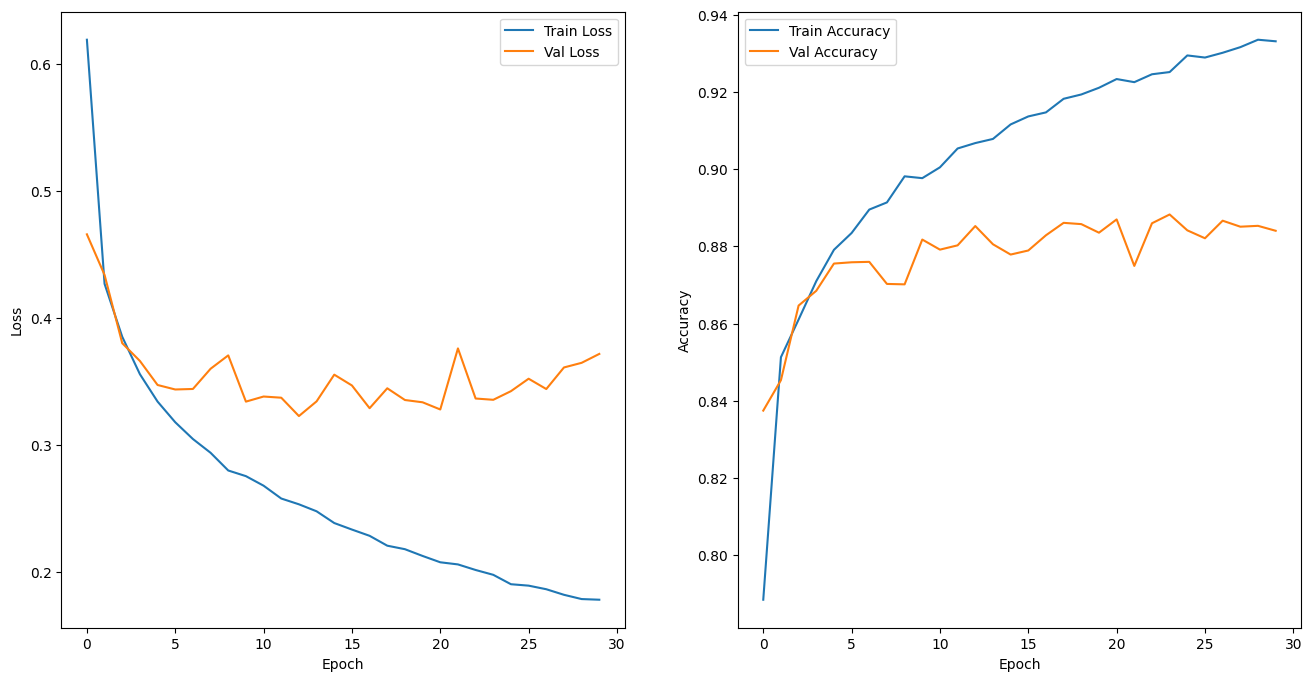

In [237]:
plot_history(history)

In [238]:
y_pred = model.predict(X_test)
y_pred[:1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[2.1617028e-08, 2.3939871e-12, 1.3279323e-06, 3.2442635e-09,
        1.4639722e-06, 5.1294419e-06, 1.4218368e-07, 3.0523811e-03,
        3.3294791e-07, 9.9693918e-01]], dtype=float32)

In [239]:
y_pred_argmax = np.argmax(y_pred, axis=1)
y_pred_argmax[:10]

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

<Figure size 600x600 with 0 Axes>

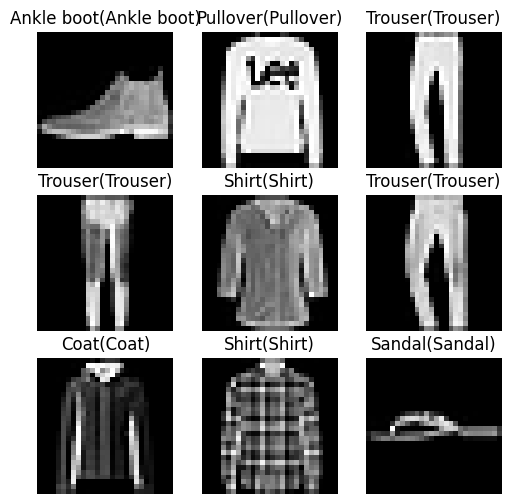

In [240]:
n_rows = 3
n_cols = 3
plt.figure(figsize=(n_cols * 2, n_rows * 2))
plt.figure(figsize=(n_cols * 2, n_rows * 2))
for row in range(n_rows):
  for col in range(n_cols):
    index = n_cols * row + col
    plt.subplot(n_rows, n_cols, index + 1)
    plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
    plt.axis('off')
    plt.title(f'{class_names[y_pred_argmax[index]]}({class_names[y_test[index]]})')
plt.show()